## **Books Sales and Ratings**
#### *Books DataSet - Analyzing Sales, Ratings, and Genres*

In [4]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
df =  pd.read_csv("Books_Data_Clean.csv")
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [7]:
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [8]:
df = df[df["Publishing Year"] > 1900]
df.describe()

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000
mean,535.926660,1994.730426,4.012230,94817.793855,1832.644985,841.360638,4.844311,613.314172,9744.482656
std,308.769358,23.204719,0.246492,31473.890412,3947.885096,2279.579848,3.561712,369.628663,15350.021050
min,0.000000,1901.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,271.000000,1989.000000,3.860000,70701.000000,366.300000,0.000000,1.990000,291.000000,570.000000
50%,535.000000,2003.000000,4.030000,89204.000000,792.000000,273.240000,3.990000,596.000000,3942.000000
75%,802.000000,2010.000000,4.180000,113400.000000,1470.260000,714.756000,6.990000,933.000000,5427.000000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 1009 entries, 0 to 1069
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   index                1009 non-null   int64  
 1   Publishing Year      1009 non-null   float64
 2   Book Name            988 non-null    str    
 3   Author               1009 non-null   str    
 4   language_code        960 non-null    str    
 5   Author_Rating        1009 non-null   str    
 6   Book_average_rating  1009 non-null   float64
 7   Book_ratings_count   1009 non-null   int64  
 8   genre                1009 non-null   str    
 9   gross sales          1009 non-null   float64
 10  publisher revenue    1009 non-null   float64
 11  sale price           1009 non-null   float64
 12  sales rank           1009 non-null   int64  
 13  Publisher            1009 non-null   str    
 14  units sold           1009 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 126.1 KB

In [10]:
df.shape

(1009, 15)

In [11]:
# checking for null values
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [12]:
# dropping rows where book name is null(the easiest way to do this) 
# not dropping rows with language code because a lot of data -- 49 rows -- will be deleted

df.dropna(subset="Book Name", inplace = True)

##### The dropna() method removes the rows that contains NULL values. 
##### The dropna() method returns a new DataFrame object unless the inplace parameter is set to True,
##### in that case the dropna() method does the removing in the original DataFrame instead.

In [13]:
df.duplicated().sum()
# op shows that there are no duplicate values

np.int64(0)

In [14]:
# finding unique values 
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

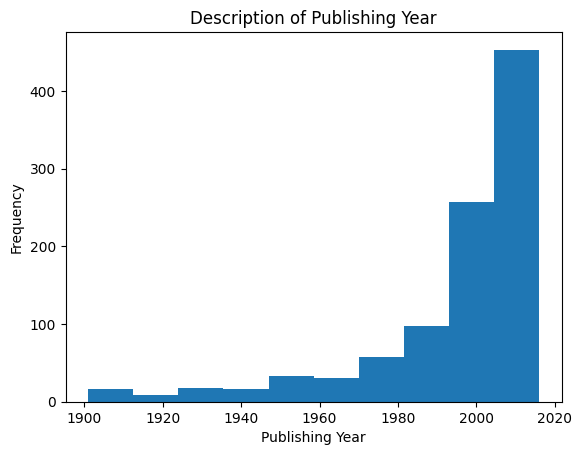

In [15]:
# creating a histogram to see the distribution of publishing year

plt.hist(df["Publishing Year"])
plt.xlabel("Publishing Year")
plt.ylabel("Frequency")
plt.title("Description of Publishing Year")
plt.show()

#### **The output shows that we have more books which were published in the recent years i.e. in the 2000's, their amount being twice as those published in the 90's**

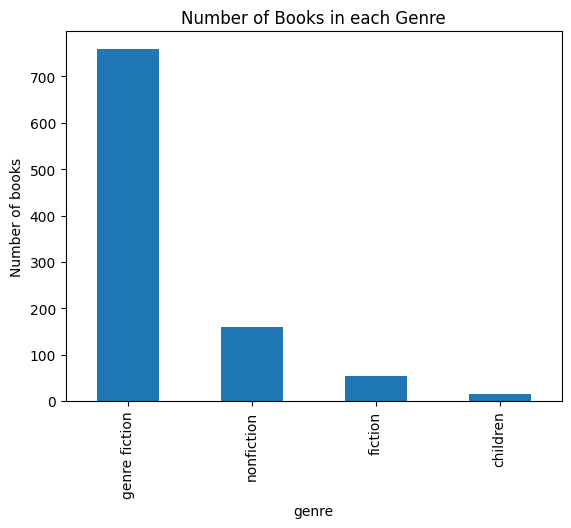

In [16]:
# generating bar plot for the book genre

df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("genre")
plt.ylabel("Number of books")
plt.title("Number of Books in each Genre")
plt.show()

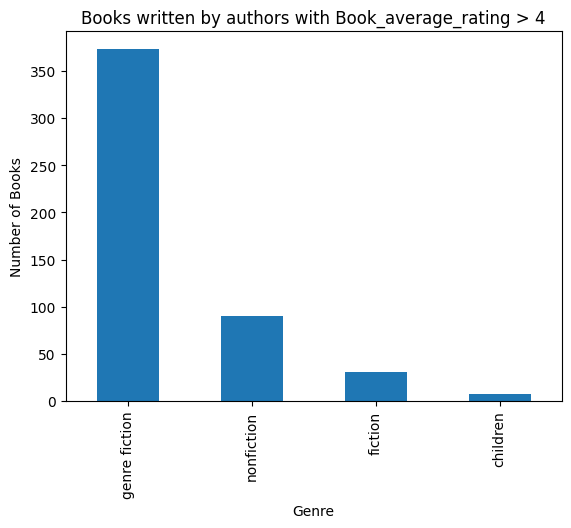

In [17]:
# Grouping by athors and cheking their avg rating ....also finding what genre of books do authors with high avg rating write

# Step 1 : Average rating per author
avg_rating = df.groupby("Author")["Book_average_rating"].mean()

# Step 2: Authors with avg rating > 4
high_avg_authors = avg_rating[avg_rating > 4].index

# Step 3: Filter dataframe
filtered_df = df[df["Author"].isin(high_avg_authors)]

# Step 4: Count genres
genre_count = filtered_df["genre"].value_counts().plot(kind = "bar")
plt.xlabel("Genre")
plt.ylabel("Number of Books")
plt.title("Books written by authors with Book_average_rating > 4")
plt.show()


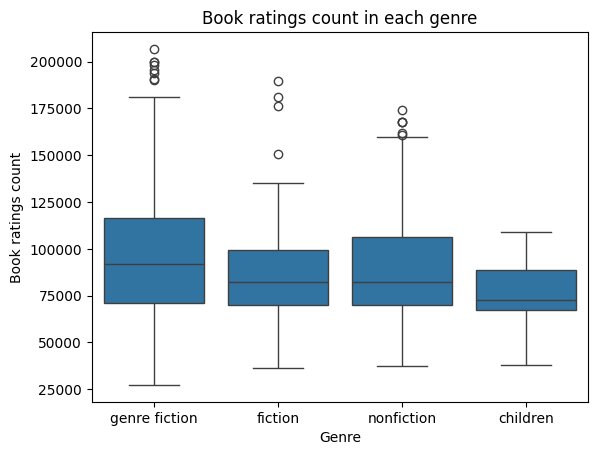

In [18]:
# books raating count in each genre

sns.boxplot( x = "genre", y = "Book_ratings_count", data = df)
plt.xlabel("Genre")
plt.ylabel("Book ratings count")
plt.title("Book ratings count in each genre")
plt.show()

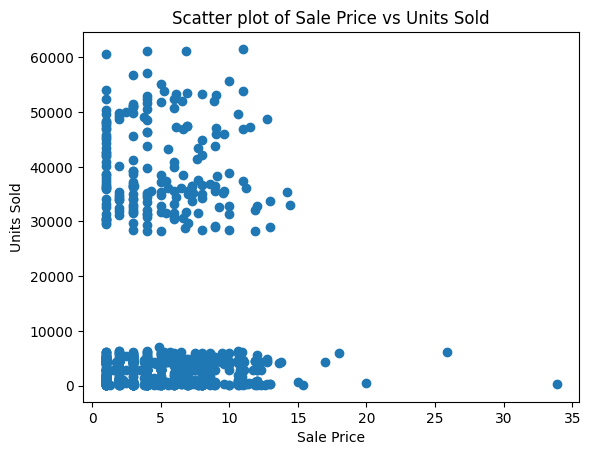

In [19]:
plt.scatter(df["sale price"],  df['units sold'])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.title("Scatter plot of Sale Price vs Units Sold")
plt.show()

#### *This shows that when the sale price is low more books are sold*

In [20]:
#pie plot for language code

language_counts = df["language_code"].value_counts().sort_values()

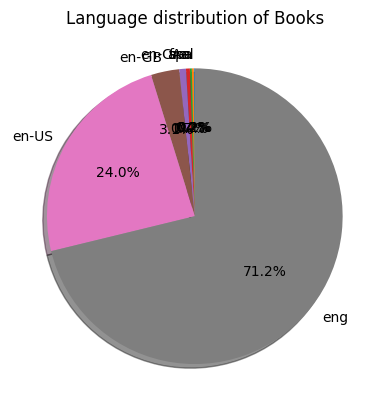

In [21]:
plt.pie(language_counts, labels = language_counts.index, startangle = 90, autopct = "%1.1f%%", shadow = True)
       # pctdistance = 1, 
       # labeldistance = 2)

plt.title("Language distribution of Books")
plt.show()

In [22]:
# Grouping by publishers to find the total revenue of each publisher

df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False)

Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [23]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='str')

In [24]:
# average book count for each author rating
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending = False)

Author_Rating
Intermediate    101400.272569
Famous           98295.250000
Novice           87318.464286
Excellent        83804.800595
Name: Book_ratings_count, dtype: float64

In [25]:
#counting number of books in each language
df.groupby("language_code").size().sort_values(ascending = False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

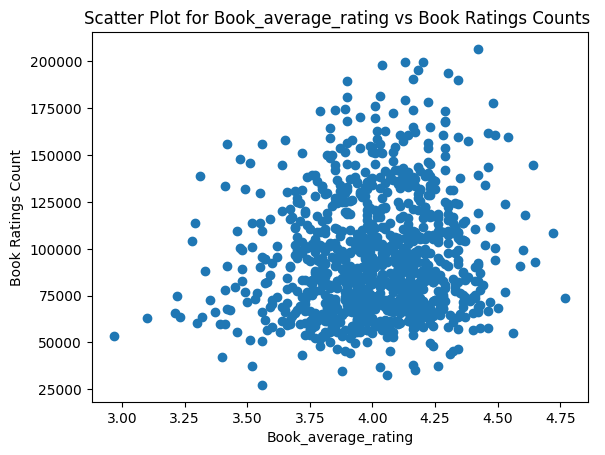

In [26]:
plt.figure()
plt.scatter(df["Book_average_rating"], df["Book_ratings_count"])

plt.xlabel("Book_average_rating")
plt.ylabel("Book Ratings Count")
plt.title("Scatter Plot for Book_average_rating vs Book Ratings Counts ")

plt.show()


In [27]:
total_gross_sales_by_author = df.groupby("Author")["gross sales"].sum()


Text(0.5, 1.0, 'Top 10 Gross sales of Authors')

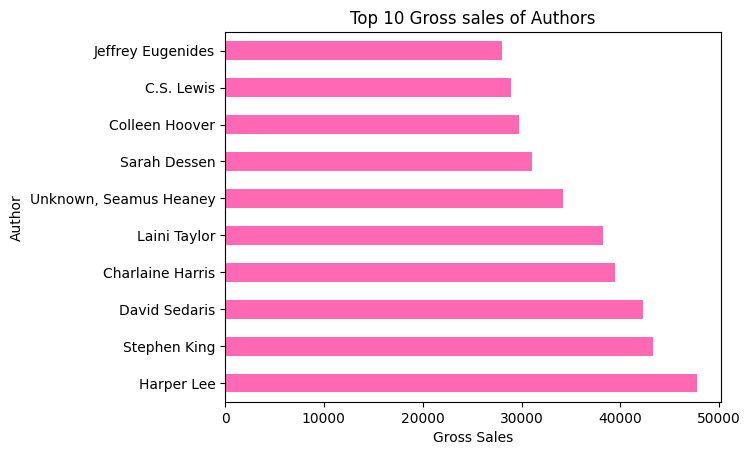

In [28]:
total_gross_sales_by_author.sort_values(ascending=False).head(10).plot(kind = "barh", color='hotpink')
plt.ylabel("Author")
plt.xlabel("Gross Sales")
plt.title("Top 10 Gross sales of Authors")

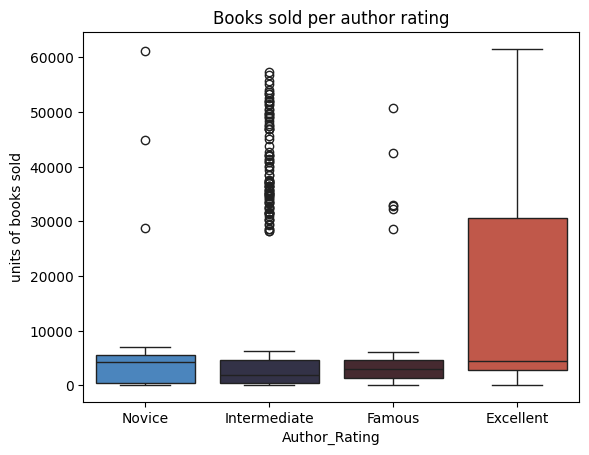

In [36]:
# df.columns
sns.boxplot(x = "Author_Rating", y = 'units sold', data = df,hue = "Author_Rating" ,palette = "icefire")

plt.xlabel("Author_Rating")
plt.ylabel("units of books sold")
plt.title("Books sold per author rating")
plt.show()

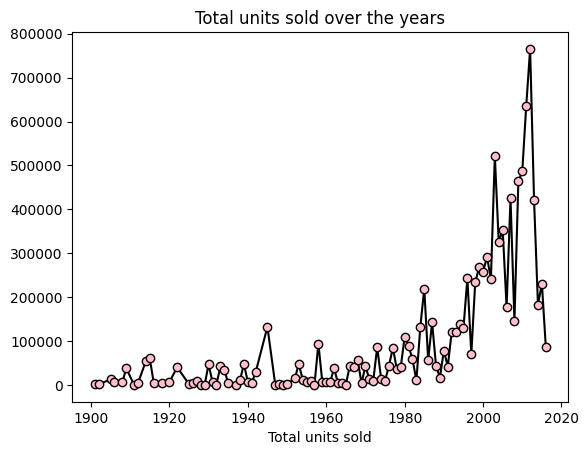

In [40]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind = "line", marker = "o",
                                                      markeredgecolor = 'black',
                                                      markerfacecolor = 'pink',
                                                      color = "black")
plt.xlabel("Publishing Year")
plt.xlabel("Total units sold")
plt.title("Total units sold over the years")
plt.show()